# Autoencoder (AE) - MNIST Image Reconstruction

This project builds a fully connected Autoencoder to learn compact latent representations of handwritten digits from the MNIST dataset. The objective is to compress input images into a low-dimensional latent space and reconstruct them while minimizing reconstruction error.


## 1. Import Required Libraries

Import the libraries required for data processing, visualization, model development and evaluation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
print(tf.__version__)

2.21.0


## 2. Load the MNIST Dataset

Load the official TensorFlow MNIST dataset.

In [2]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape((-1,784))
x_test=x_test.reshape((-1,784))
x_train,x_val=train_test_split(x_train,test_size=0.2,random_state=42)

## 3. Explore the Dataset

Visualize sample handwritten digits.

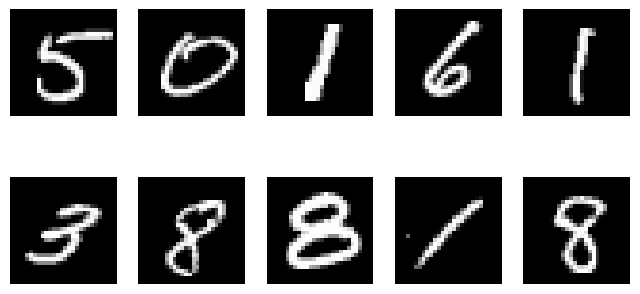

In [3]:
fig,ax=plt.subplots(2,5,figsize=(8,4))
for i,a in enumerate(ax.flat):
    a.imshow(x_train[i].reshape(28,28),cmap="gray")
    a.axis("off")
plt.show()

## 4. Build the Autoencoder

Create the encoder, bottleneck and decoder.

In [4]:
inp=Input(shape=(784,))
x=Dense(256,activation="relu")(inp)
x=Dense(128,activation="relu")(x)
latent=Dense(64,activation="relu",name="latent_space")(x)
x=Dense(128,activation="relu")(latent)
x=Dense(256,activation="relu")(x)
out=Dense(784,activation="sigmoid")(x)

autoencoder=Model(inp,out)
autoencoder.compile(optimizer="adam",loss="mse")
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

Train using reconstruction loss with EarlyStopping.

In [5]:
history=autoencoder.fit(
x_train,x_train,
validation_data=(x_val,x_val),
epochs=30,
batch_size=256,
callbacks=[EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)]
)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0624 - val_loss: 0.0337
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0261 - val_loss: 0.0215
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0194 - val_loss: 0.0178
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0165 - val_loss: 0.0155
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0144 - val_loss: 0.0136
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0128 - val_loss: 0.0124
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0118 - val_loss: 0.0114
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0109 - val_loss: 0.0107
Epoch 9/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0102 - val_loss: 0.0101
Epoch 10/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0097 - val_loss: 0.0096
Epoch 11/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0092 - val_loss: 0.0094
Epoch 12/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/st

## 6. Training Curves

Visualize training and validation loss.

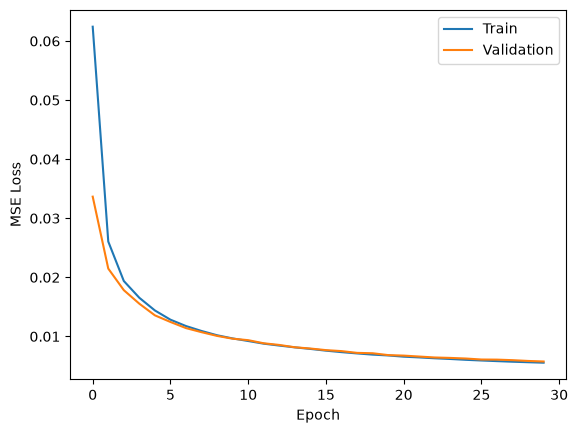

In [6]:
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## 7. Reconstruct Test Images

Generate reconstructed images.

In [7]:
reconstructed=autoencoder.predict(x_test,verbose=0)

## 8. Visual Comparison

Compare original and reconstructed images.

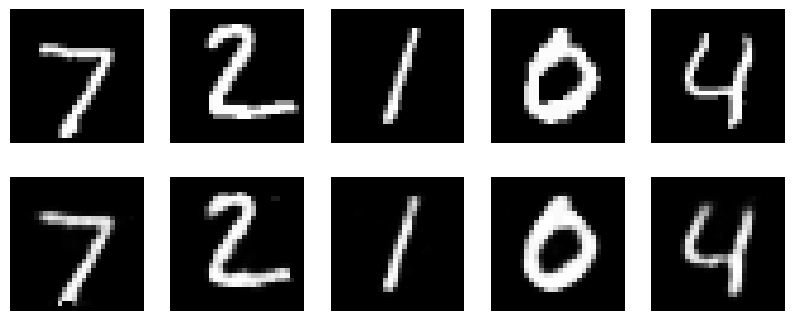

In [8]:
n=5
fig,ax=plt.subplots(2,n,figsize=(10,4))
for i in range(n):
    ax[0,i].imshow(x_test[i].reshape(28,28),cmap="gray")
    ax[0,i].axis("off")
    ax[1,i].imshow(reconstructed[i].reshape(28,28),cmap="gray")
    ax[1,i].axis("off")
ax[0,0].set_ylabel("Original")
ax[1,0].set_ylabel("Reconstructed")
plt.show()

## 9. Reconstruction Error Analysis

Compute reconstruction error.

Mean Reconstruction Error: 0.005511


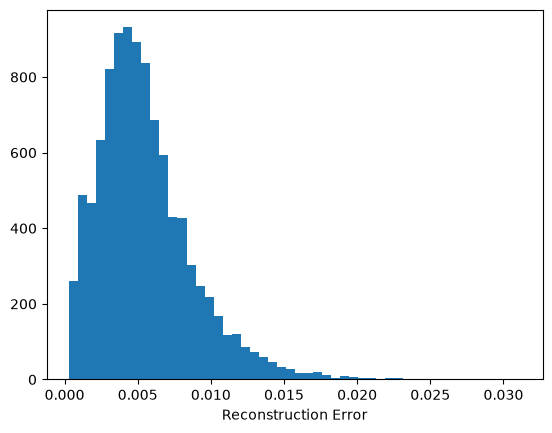

In [9]:
mse=np.mean(np.square(x_test-reconstructed),axis=1)
print(f"Mean Reconstruction Error: {mse.mean():.6f}")
plt.hist(mse,bins=50)
plt.xlabel("Reconstruction Error")
plt.show()

## 10. Latent Representation

Create an encoder model and inspect latent vectors.

In [10]:
encoder=Model(inp,latent)
latent_vectors=encoder.predict(x_test[:5],verbose=0)
print(latent_vectors.shape)
print(latent_vectors[0])

(5, 64)
[ 5.5868297  0.         6.1580653  5.616092   5.5893106  4.079075
  1.5225812  7.18728    3.6488583  2.7408397  6.216424   0.
  2.297482   6.3025517  3.6047983  0.         7.952465   3.6508584
  7.116294   2.7248785  1.3178719  8.138586   9.865892   0.
  0.         5.437987   6.5436707  6.9081135 11.95093    0.
  7.884429   9.968032   9.809175   6.1629233  4.272872   8.236978
 11.2795     0.         0.         8.788468   9.023595   0.
  7.764725   5.809948   2.8634524  0.         4.8030486 10.782012
  5.788722   8.617793   0.         2.191661   0.         8.760567
  9.949555   0.         6.757208   0.         7.942262   3.573562
  5.4942336  5.4988294  3.6323376  5.39373  ]


## 11. Model Evaluation

Summarize the reconstruction performance.

In [11]:
print(f"Validation Loss: {min(history.history['val_loss']):.6f}")

Validation Loss: 0.005753


# 12. Discussion

The Autoencoder achieved a mean reconstruction error of **0.005511** on the test set, indicating that the network was able to reconstruct the normalized MNIST images with relatively low pixel-level error. The validation loss reached **0.005753**, while the training and validation loss curves followed a similar downward trend, suggesting that the model learned a useful representation without a substantial divergence between training and validation performance.

The architecture compresses each 784-dimensional image into a **64-dimensional latent representation** before reconstructing it through the decoder. The reconstructed samples retain the primary structure of the original digits, although some fine details are lost during compression. This behaviour is consistent with the objective of an Autoencoder: preserving the most informative features while representing the input using a lower-dimensional latent space.

# 13. Key Findings

- The Autoencoder achieved a **mean reconstruction error of 0.005511** on the test set.
- The minimum validation loss reached **0.005753**, indicating low reconstruction error on unseen validation data.
- The training and validation loss curves showed consistent convergence without a substantial generalization gap.
- The **784-dimensional input** was compressed into a **64-dimensional latent representation**, reducing the representation size while retaining the main visual structure of the handwritten digits.
- Reconstructed images preserved the overall shape and identity of the digits, although some fine-grained visual details were lost during compression.
- Reconstruction errors varied across samples, indicating that the learned latent representation captures common MNIST patterns more effectively than unusual or visually complex writing styles.

# 14. Conclusion

This project demonstrates how an Autoencoder can learn a compact representation of image data without requiring class labels as a prediction target. The model compressed 784-dimensional MNIST images into a 64-dimensional latent representation and reconstructed the test images with a mean reconstruction error of **0.005511**.

The results show that the learned representation retained the dominant structural characteristics of the handwritten digits while reducing the dimensionality of the input substantially. This provides a foundation for more advanced representation-learning methods, where the objective moves beyond basic reconstruction toward learning robust representations under corrupted inputs and eventually structured latent spaces.